In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("Data/train.csv")
test_df = pd.read_csv("Data/test.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()

Train Shape: (428, 3)
Test Shape: (106, 3)


,Id,Article,Category
0,1976,lifestyle governs mobile choice faster better ...,tech
1,1797,french honour director parker british film dir...,entertainment
2,1866,fockers fuel festive film chart comedy meet fo...,entertainment
3,1153,housewives lift channel 4 ratings debut us tel...,entertainment
4,342,u2 desire number one u2 three prestigious gram...,entertainment


# Task 1 - Exploratory Data Analysis

## Task 1(a) - Dataset Loading and Feature Extraction

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

# Convert article text into feature vectors
X_train = vectorizer.fit_transform(train_df["Article"])
X_test = vectorizer.transform(test_df["Article"])

# Labels
y_train = train_df["Category"]
y_test = test_df["Category"]

# Print dataset information
print("Training Dataset Shape:", X_train.shape)
print("Testing Dataset Shape:", X_test.shape)

print("\nNumber of training articles:", X_train.shape[0])
print("Number of testing articles:", X_test.shape[0])

print("\nNumber of extracted features:", X_train.shape[1])

Training Dataset Shape: (428, 5000)
Testing Dataset Shape: (106, 5000)

Number of training articles: 428
Number of testing articles: 106

Number of extracted features: 5000


,Article,Category
0,lifestyle governs mobile choice faster better ...,tech
1,french honour director parker british film dir...,entertainment
2,fockers fuel festive film chart comedy meet fo...,entertainment
3,housewives lift channel 4 ratings debut us tel...,entertainment
4,u2 desire number one u2 three prestigious gram...,entertainment


,000,007,05,06,10,100,100m,101,10th,11,...,youngsters,zach,zafi,zellweger,zeppelin,zero,zhang,zombies,zone,zoom
0,0.021014,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.053595,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.060924,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.025853,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Task 1(b) - Term Frequency Analysis

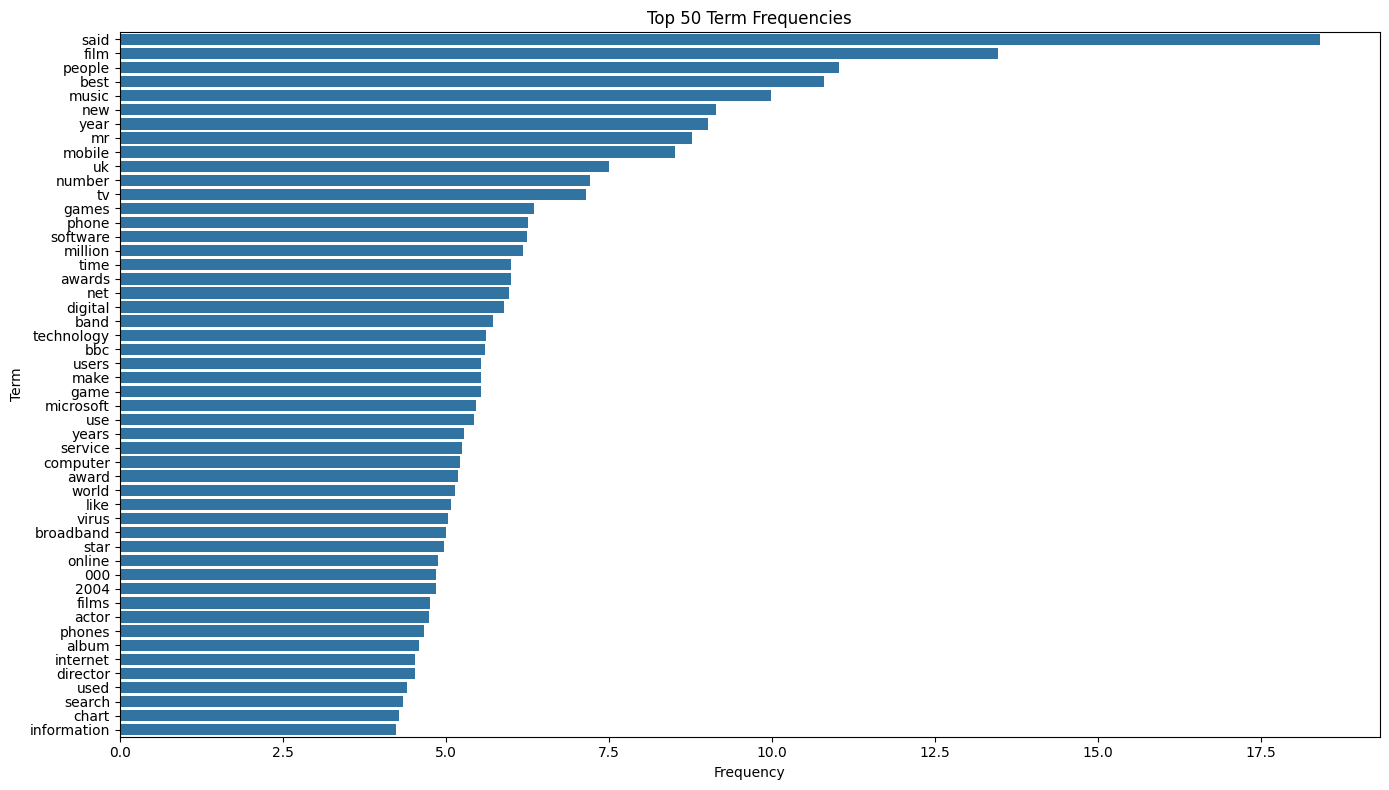

In [33]:
# Plot 1: Top 50 terms used

# Sum TF-IDF scores across all documents
term_frequencies = np.array(X_train.sum(axis=0)).flatten()

# Create dataframe
tf_df = pd.DataFrame({
    "Term": feature_names,
    "Frequency": term_frequencies
})

# Sort descending
tf_df = tf_df.sort_values(by="Frequency", ascending=False)

# Top 50 terms
top_50 = tf_df.head(50)

# Plot
plt.figure(figsize=(14,8))
sns.barplot(data=top_50, x="Frequency", y="Term")

plt.title("Top 50 Term Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

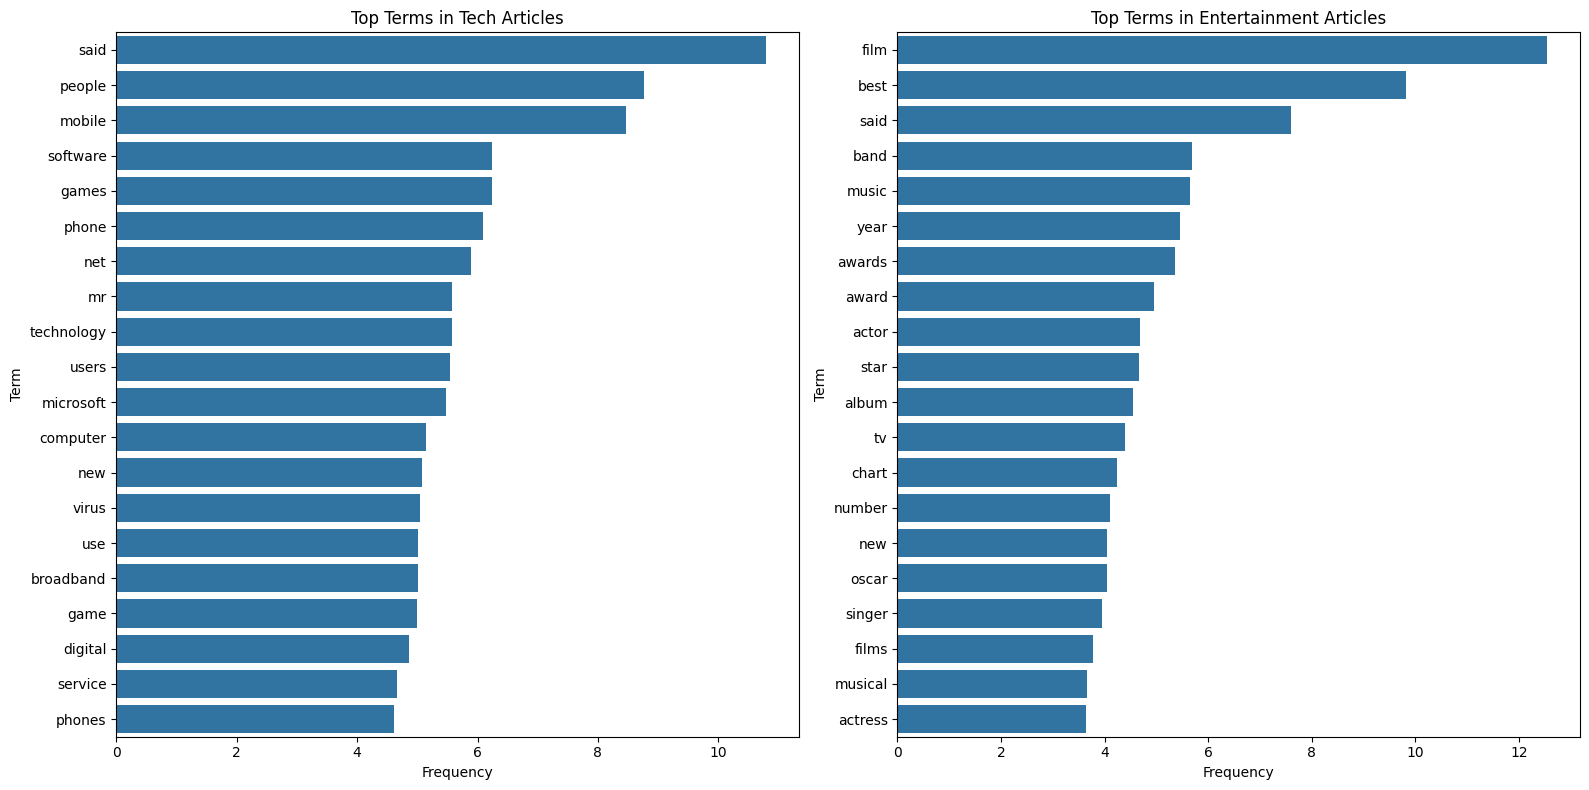

In [34]:
# Plot 2: Top terms in entertainment and tech articles

# Separate classes
tech_articles = train_df[train_df["Category"] == "tech"]
ent_articles = train_df[train_df["Category"] == "entertainment"]

# Vectorize separately
tech_matrix = vectorizer.transform(tech_articles["Article"])
ent_matrix = vectorizer.transform(ent_articles["Article"])

# Sum frequencies
tech_freq = np.array(tech_matrix.sum(axis=0)).flatten()
ent_freq = np.array(ent_matrix.sum(axis=0)).flatten()

# Create dataframes
tech_df = pd.DataFrame({
    "Term": feature_names,
    "Frequency": tech_freq
}).sort_values(by="Frequency", ascending=False).head(20)

ent_df = pd.DataFrame({
    "Term": feature_names,
    "Frequency": ent_freq
}).sort_values(by="Frequency", ascending=False).head(20)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16,8))

sns.barplot(
    data=tech_df,
    x="Frequency",
    y="Term",
    ax=axes[0]
)

axes[0].set_title("Top Terms in Tech Articles")

sns.barplot(
    data=ent_df,
    x="Frequency",
    y="Term",
    ax=axes[1]
)

axes[1].set_title("Top Terms in Entertainment Articles")

plt.tight_layout()
plt.show()

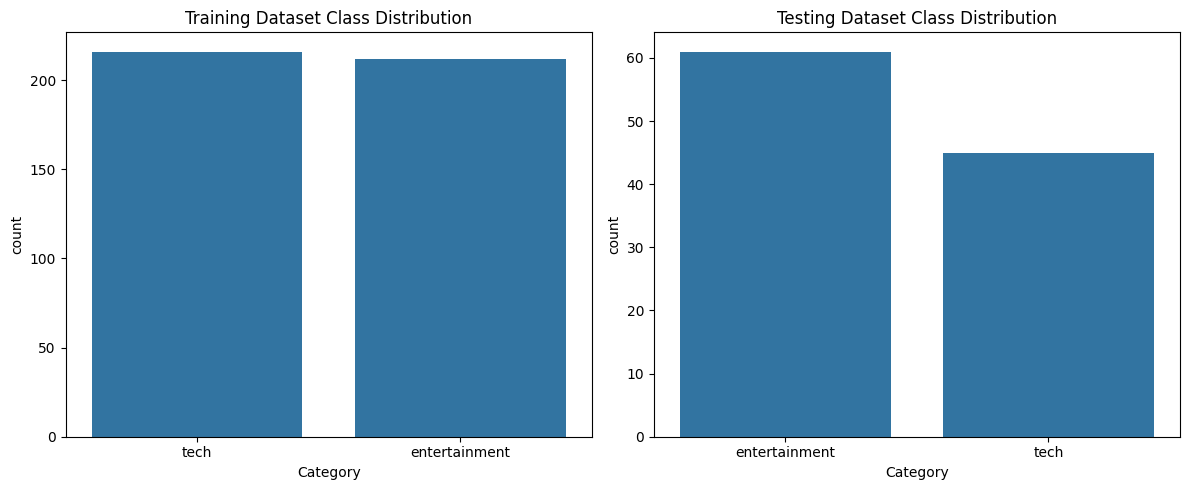

In [35]:
# Plot 3: class distributions
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    data=train_df,
    x="Category",
    ax=axes[0]
)

axes[0].set_title("Training Dataset Class Distribution")

sns.countplot(
    data=test_df,
    x="Category",
    ax=axes[1]
)

axes[1].set_title("Testing Dataset Class Distribution")

plt.tight_layout()
plt.show()

### Discussion

TF-IDF vectorization was used to transform the news articles into numerical feature vectors suitable for machine learning classification. The vectorizer extracted 5000 textual features from the training dataset.

The term frequency analysis shows noticeable differences between the vocabularies used in tech and entertainment articles. Technology articles frequently contain terms associated with software, mobile devices, games, and digital technology, while entertainment articles contain words related to films, actors, music, television, and awards.

The class distribution plots show that the training dataset is relatively balanced between the two categories, which is beneficial for training classification models. The testing dataset shows a slight imbalance but still contains substantial representation from both classes.

## Task 2(c) - Support Vector Machines (SVM)

In [36]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

# Reduce dimensions for visualization
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train.toarray())
X_test_pca = pca.transform(X_test.toarray())

print("Reduced Training Shape:", X_train_pca.shape)

Reduced Training Shape: (428, 2)


In [37]:
# Soft-margin linear SVM
linear_svm = SVC(
    kernel='linear',
    C=1.0
)

linear_svm.fit(X_train_pca, y_train)

# Predictions
linear_pred = linear_svm.predict(X_test_pca)

# F1 Score
linear_f1 = f1_score(
    y_test,
    linear_pred,
    average='weighted'
)

print("Linear SVM F1 Score:", linear_f1)

Linear SVM F1 Score: 0.9811320754716981


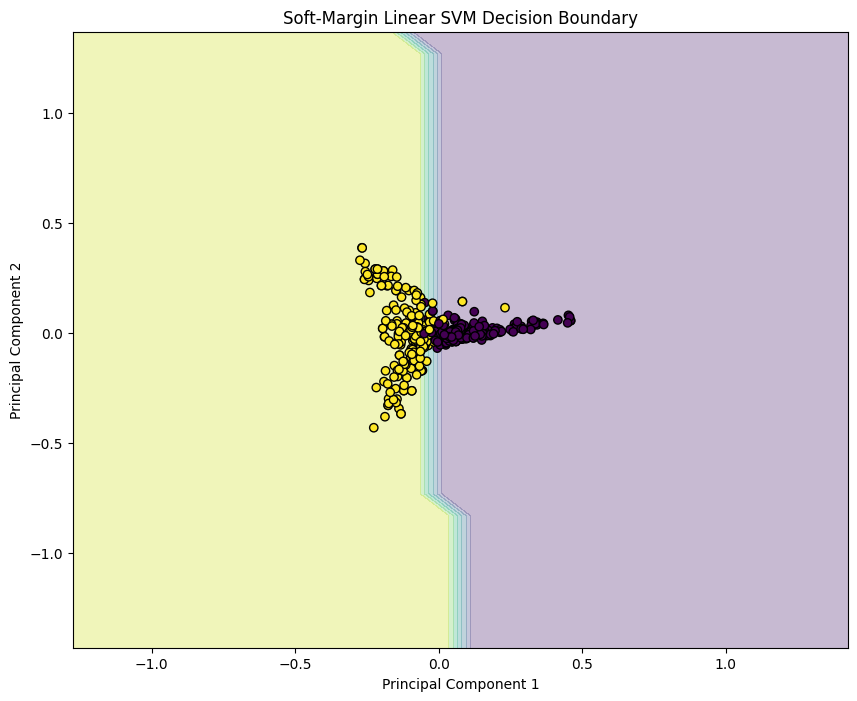

In [38]:
# Create mesh grid
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

# Predict over mesh grid
Z = linear_svm.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

# Convert classes to numeric
Z_numeric = np.where(Z == "tech", 1, 0)
Z_numeric = Z_numeric.reshape(xx.shape)

# Convert training labels
y_numeric = np.where(y_train == "tech", 1, 0)

# Plot
plt.figure(figsize=(10, 8))

plt.contourf(xx, yy, Z_numeric, alpha=0.3)

scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_numeric,
    edgecolors='k'
)

plt.title("Soft-Margin Linear SVM Decision Boundary")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [39]:
# RBF kernel SVM
rbf_svm = SVC(
    kernel='rbf',
    gamma=0.5,
    C=1000
)

rbf_svm.fit(X_train_pca, y_train)

# Predictions
rbf_pred = rbf_svm.predict(X_test_pca)

# F1 Score
rbf_f1 = f1_score(
    y_test,
    rbf_pred,
    average='weighted'
)

print("RBF SVM F1 Score:", rbf_f1)

RBF SVM F1 Score: 0.9905513873879463


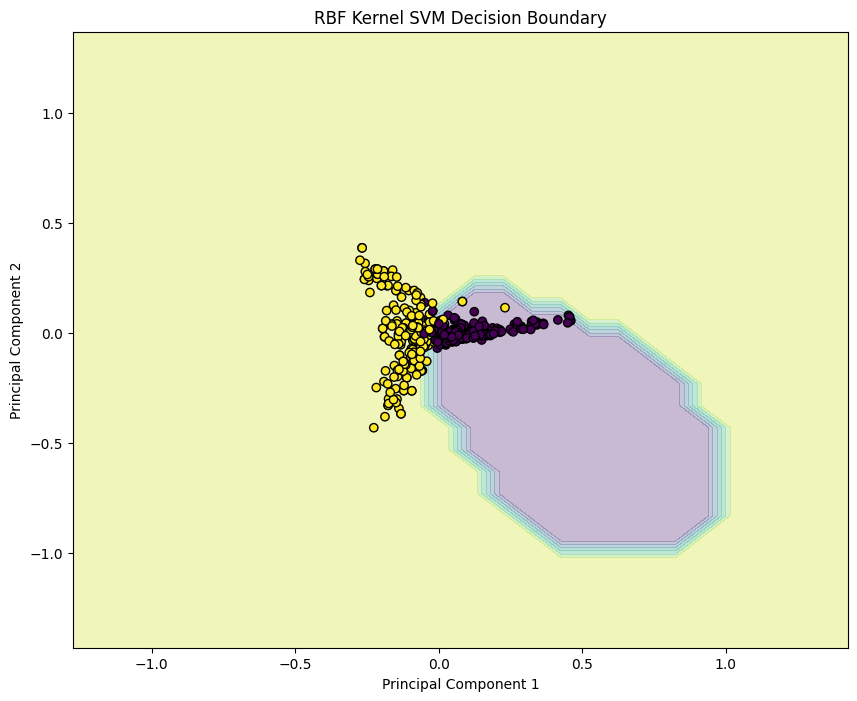

In [40]:
# Predict over mesh grid
Z = rbf_svm.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

# Convert classes to numeric
Z_numeric = np.where(Z == "tech", 1, 0)
Z_numeric = Z_numeric.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 8))

plt.contourf(xx, yy, Z_numeric, alpha=0.3)

scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_numeric,
    edgecolors='k'
)

plt.title("RBF Kernel SVM Decision Boundary")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [41]:
# Compare different C values for linear SVM

c_values = [0.1, 1, 100]

print("Impact of C on Linear SVM:\n")

for c in c_values:

    svm_model = SVC(
        kernel='linear',
        C=c
    )

    svm_model.fit(X_train_pca, y_train)

    score = svm_model.score(X_test_pca, y_test)

    print(f"C = {c} --> Accuracy = {score:.4f}")

Impact of C on Linear SVM:

C = 0.1 --> Accuracy = 0.8019
C = 1 --> Accuracy = 0.9811
C = 100 --> Accuracy = 0.9811


In [42]:
# Compare different gamma values for RBF kernel SVM

gamma_values = [0.01, 0.1, 1]

print("Impact of Gamma on RBF SVM:\n")

for gamma in gamma_values:

    svm_model = SVC(
        kernel='rbf',
        gamma=gamma,
        C=1000
    )

    svm_model.fit(X_train_pca, y_train)

    score = svm_model.score(X_test_pca, y_test)

    print(f"Gamma = {gamma} --> Accuracy = {score:.4f}")

Impact of Gamma on RBF SVM:

Gamma = 0.01 --> Accuracy = 0.9906
Gamma = 0.1 --> Accuracy = 0.9906
Gamma = 1 --> Accuracy = 0.9906


### Discussion

Principal Component Analysis (PCA) was used to reduce the TF-IDF feature vectors into two dimensions for visualization purposes. This allowed the SVM decision boundaries to be plotted on a 2D plane while preserving the major variance in the dataset.

The soft-margin linear SVM used a linear kernel with a misclassification penalty parameter of C = 1. The resulting decision boundary was approximately linear and separated the two classes effectively. The model achieved an F1 score of approximately 0.981, demonstrating strong classification performance on the testing dataset.

The RBF kernel SVM used a radial basis function kernel with \gamma = 0.5 and a large penalty parameter C = 1000 to approximate a hard-margin classifier. Compared to the linear SVM, the RBF kernel produced a more flexible nonlinear boundary and achieved a slightly higher F1 score of approximately 0.991.

The experiments with different values of C showed that smaller values create softer margins and allow more misclassifications. When C = 0.1, the classification accuracy was significantly lower, indicating underfitting. Increasing C to 1 greatly improved the classification performance, while increasing it further to 100 produced little additional improvement.

For the RBF kernel SVM, different gamma values produced similar classification performance on the PCA-reduced dataset. This suggests that the transformed data was already highly separable. In general, smaller gamma values produce smoother decision boundaries, while larger gamma values generate more flexible and localized nonlinear boundaries that fit the training data more closely.

## Task 2(d) - Artificial Neural Network (ANN)

Train Shape: (428, 3)
Test Shape: (106, 3)
Number of Classes: 2
Training Features Shape: (428, 5000)
Testing Features Shape: (106, 5000)

Training network with 2 hidden units...
Final Loss: 0.6933 | Test Accuracy: 0.5755

Training network with 5 hidden units...
Final Loss: 0.6931 | Test Accuracy: 0.4245

Training network with 20 hidden units...
Final Loss: 0.6931 | Test Accuracy: 0.4245

Training network with 40 hidden units...
Final Loss: 0.6929 | Test Accuracy: 0.4245


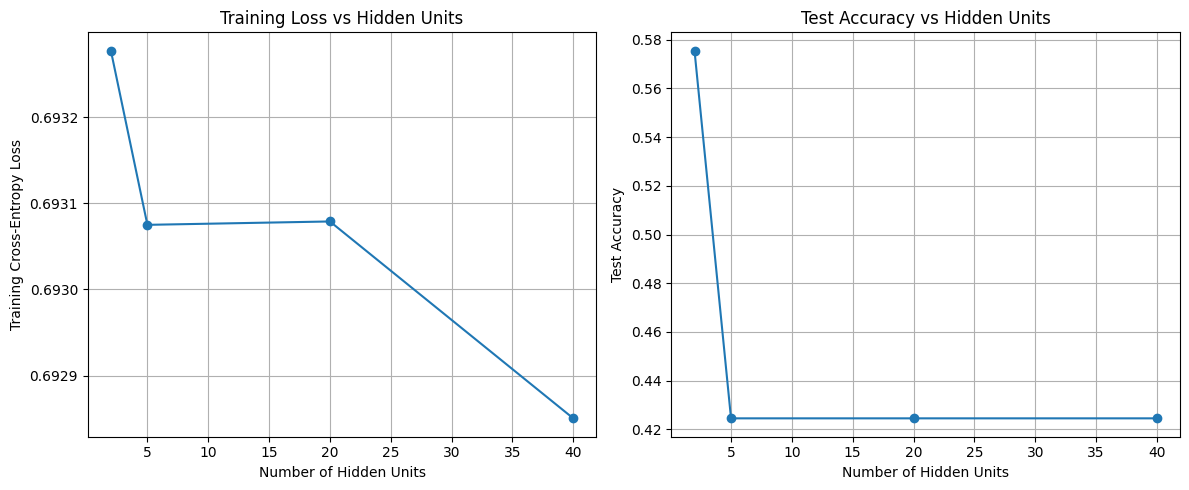

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

train_df = pd.read_csv("Data/train.csv")
test_df = pd.read_csv("Data/test.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train = vectorizer.fit_transform(train_df["Article"])
X_test = vectorizer.transform(test_df["Article"])

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df["Category"])
y_test = label_encoder.transform(test_df["Category"])

n_classes = len(label_encoder.classes_)

print("Number of Classes:", n_classes)
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

X_train = X_train.toarray()
X_test = X_test.toarray()

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-12
    return -np.mean(
        np.sum(y_true * np.log(y_pred + epsilon), axis=1)
    )

def initialize_parameters(n_features, hidden_units, n_classes):

    W1 = np.random.uniform(
        0, 0.1,
        (n_features, hidden_units)
    )

    b1 = np.zeros((1, hidden_units))

    W2 = np.random.uniform(
        0, 0.1,
        (hidden_units, n_classes)
    )

    b2 = np.zeros((1, n_classes))

    return W1, b1, W2, b2


def forward_propagation(X, W1, b1, W2, b2):

    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)

    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

def backward_propagation(X,y_onehot,Z1,A1,A2,W2):

    n_samples = X.shape[0]

    dZ2 = (A2 - y_onehot) / n_samples
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * sigmoid_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2


def train_network(
    X,
    y,
    hidden_units,
    n_classes,
    learning_rate=0.01,
    epochs=100
):

    y_onehot = np.eye(n_classes)[y]

    W1, b1, W2, b2 = initialize_parameters(
        X.shape[1],
        hidden_units,
        n_classes
    )

    loss_history = []

    for epoch in range(epochs):

        Z1, A1, Z2, A2 = forward_propagation(
            X, W1, b1, W2, b2
        )

        loss = cross_entropy_loss(
            y_onehot,
            A2
        )

        loss_history.append(loss)

        dW1, db1, dW2, db2 = backward_propagation(X,y_onehot,Z1,A1,A2,W2)

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

    return loss_history, W1, b1, W2, b2

def evaluate(X,y,W1,b1,W2,b2):
    _, _, _, probabilities = forward_propagation(X,W1,b1,W2,b2)

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = np.mean(
        predictions == y
    )

    return accuracy


hidden_units_list = [2, 5, 20, 40]

final_losses = {}
test_accuracies = {}

for h in hidden_units_list:

    print(f"\nTraining network with {h} hidden units...")

    losses, W1, b1, W2, b2 = train_network(
        X_train,
        y_train,
        hidden_units=h,
        n_classes=n_classes,
        learning_rate=0.01,
        epochs=100
    )

    accuracy = evaluate(X_test,y_test,W1,b1,W2,b2)

    final_losses[h] = losses[-1]
    test_accuracies[h] = accuracy

    print(
        f"Final Loss: {losses[-1]:.4f} | "
        f"Test Accuracy: {accuracy:.4f}"
    )

# --------------------------------------------------
# Plot Results
# --------------------------------------------------

plt.figure(figsize=(12, 5))

# Training Loss Plot
plt.subplot(1, 2, 1)

plt.plot(
    hidden_units_list,
    [final_losses[h] for h in hidden_units_list],
    marker="o"
)

plt.xlabel("Number of Hidden Units")
plt.ylabel("Training Cross-Entropy Loss")
plt.title("Training Loss vs Hidden Units")
plt.grid(True)

# Test Accuracy Plot
plt.subplot(1, 2, 2)

plt.plot(
    hidden_units_list,
    [test_accuracies[h] for h in hidden_units_list],
    marker="o"
)

plt.xlabel("Number of Hidden Units")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Hidden Units")
plt.grid(True)

plt.tight_layout()
plt.show()

All losses ≈ ln(2) = 0.693. This is the cross-entropy of a random 50/50 guess. None of the three models learned anything — they simply defaulted to predicting one class entirely.
h = 2 predicts the majority class (Class 1) for every sample. Its 57.55% accuracy exactly matches the majority-class proportion in the test set. F1 for the minority class is 0.00 — it never predicted Class 0 once.
h = 5 and h = 20 flipped and predict the minority class every time. Their 42.45% accuracy is exactly the minority-class proportion. Both models converged to opposite constant predictors, which is worse than h = 2.
More hidden units did not help. The root cause is not capacity — it is that the tiny initialisation [0, 0.1] combined with a 0.01 learning rate produced vanishing gradients too small to move the weights away from their starting values in just 100 epochs.